# 讀取羽球軌跡資料 (Ball Trajectory)

這份 Notebook 用於讀取並視覺化羽球的 3D 軌跡資料。
資料來源包括：
- `ball_new`: 球的 3D 位置 (T, 3)
- `ball_final_mask_new`: 球的 mask (T,)，0 表示未偵測到或是不可靠的點

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import glob

#雖然 notebook 預設工作目錄通常是檔案所在目錄，但為了保險起見，確認一下
print(f"Current working directory: {os.getcwd()}")

# 設定資料路徑
dataset_root = "." # 假設 notebook 在 dataset 根目錄
ball_dir = os.path.join(dataset_root, "ball_new")
mask_dir = os.path.join(dataset_root, "ball_final_mask_new")

print(f"Data root: {dataset_root}")
print(f"Ball directory: {ball_dir}")
print(f"Mask directory: {mask_dir}")

Current working directory: d:\王昱舜專題\badminton_dataset
Data root: .
Ball directory: .\ball_new
Mask directory: .\ball_final_mask_new


In [12]:
# 列出所有可用的場次資料夾 (Rally Folders)
if os.path.exists(ball_dir):
    rallies = [d for d in os.listdir(ball_dir) if os.path.isdir(os.path.join(ball_dir, d))]
    print(f"Found {len(rallies)} rallies:")
    print(rallies[:20]) # 列出前20個
else:
    print(f"Directory not found: {ball_dir}")


Found 31 rallies:
['241217_1', '241217_2', '241217_3', '241217_4', '241224_1', '241224_2', '241224_3', '241224_4', '241226_1', '241226_2', '250108_1', '250108_2', '250108_3', '250108_4', '250108_5', '250111_1', '250111_2', '250112_1', '250112_2', '250112_4']


In [13]:
# 選擇並載入資料
# 這裡您可以修改 rally_name 和 file_name 來查看不同的軌跡
rally_name = "241217_1"  # 範例場次
file_name = "1_00_01.npy" # 範例檔案

ball_path = os.path.join(ball_dir, rally_name, file_name)
mask_path = os.path.join(mask_dir, rally_name, file_name)

print(f"Attempting to read ball data from: {ball_path}")

# 讀取資料
if os.path.exists(ball_path) and os.path.exists(mask_path):
    ball_data = np.load(ball_path)
    mask_data = np.load(mask_path)
    
    print("--------------------------------------------------")
    print(f"Successfully loaded data for {rally_name}/{file_name}")
    print(f"Ball data shape: {ball_data.shape} (Frames, X, Y, Z)")
    print(f"Mask data shape: {mask_data.shape} (Frames,)")
    print(f"Number of valid frames: {np.sum(mask_data)}")
    print("--------------------------------------------------")
else:
    print(f"Error: Files not found! Please check if {ball_path} exists.")


Attempting to read ball data from: .\ball_new\241217_1\1_00_01.npy
--------------------------------------------------
Successfully loaded data for 241217_1/1_00_01.npy
Ball data shape: (300, 3) (Frames, X, Y, Z)
Mask data shape: (300,) (Frames,)
Number of valid frames: 185
--------------------------------------------------


Iterating over files in: ball_new\241224_1
Visualizing: 1_01_00.npy, Valid points: 544


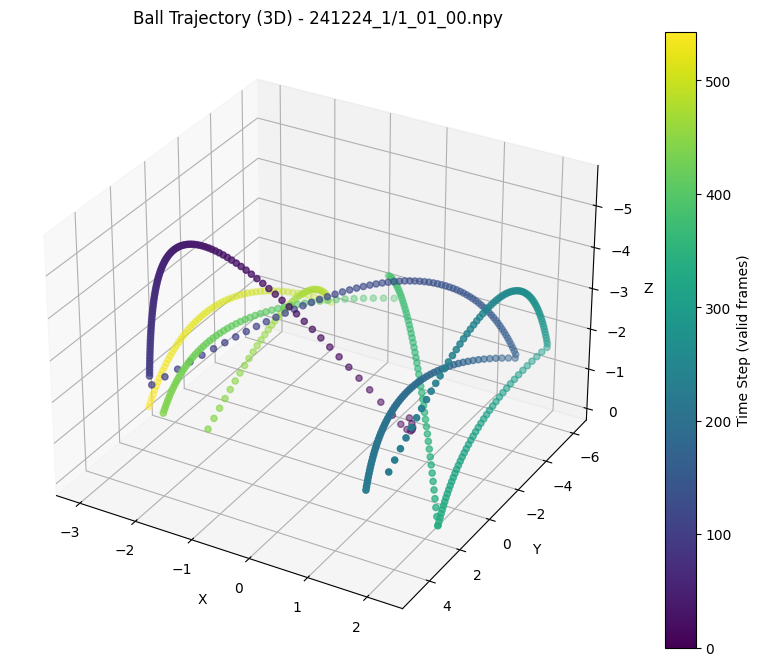

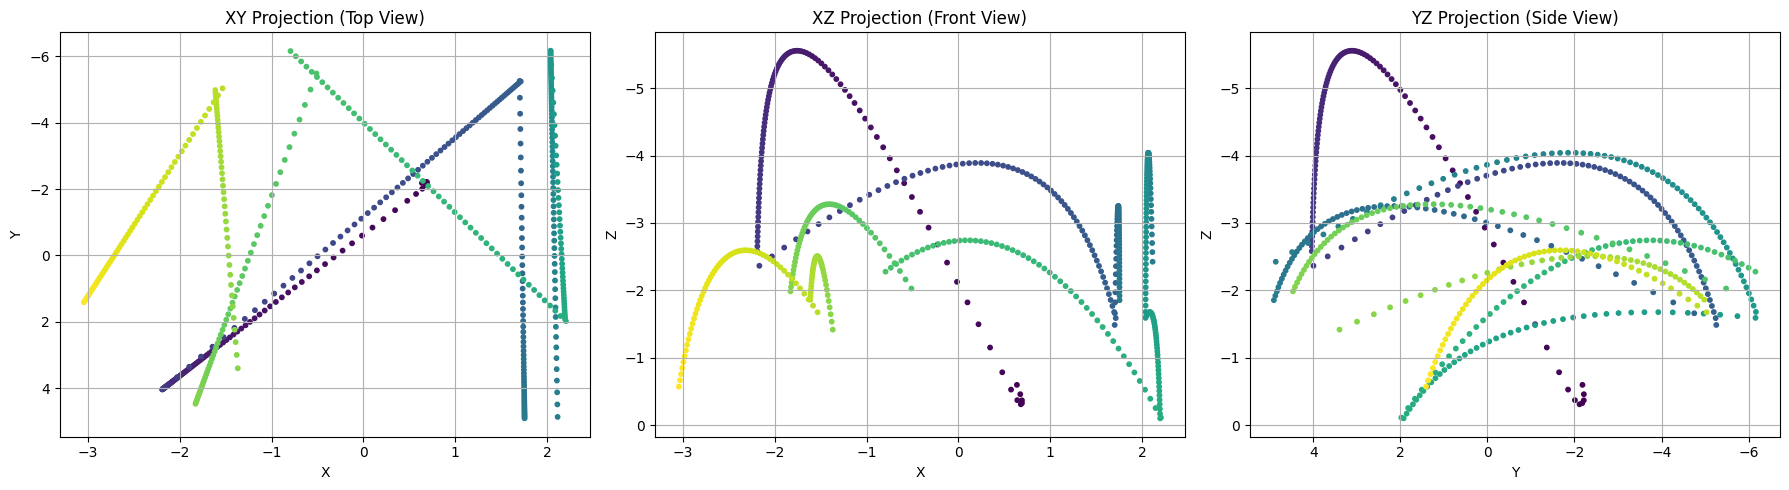

Visualizing: 1_01_01.npy, Valid points: 343


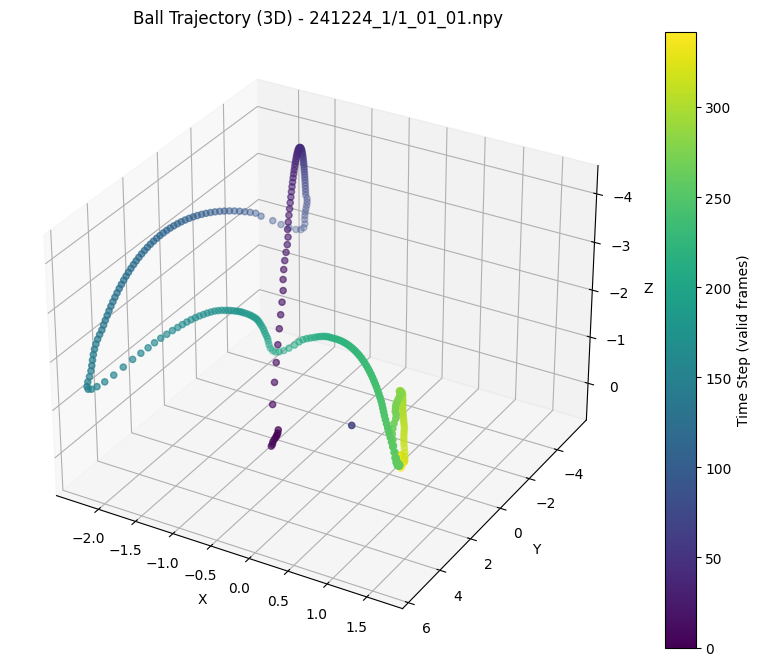

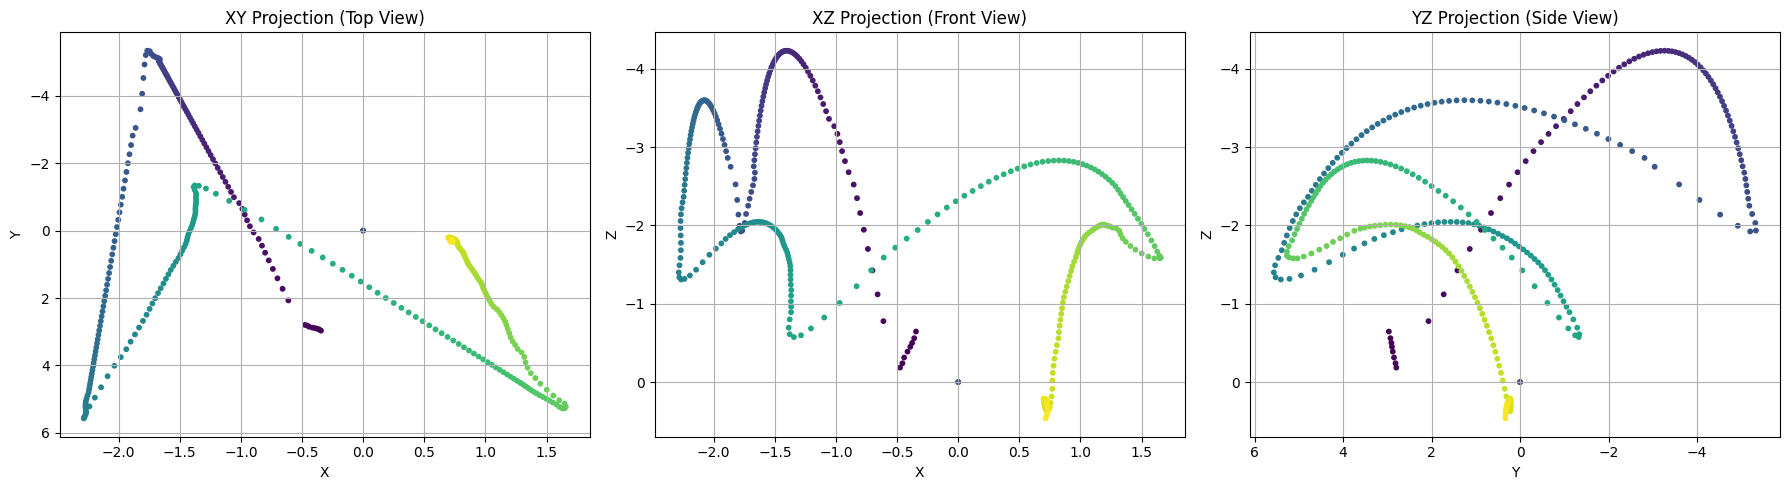

Visualizing: 1_01_02.npy, Valid points: 350


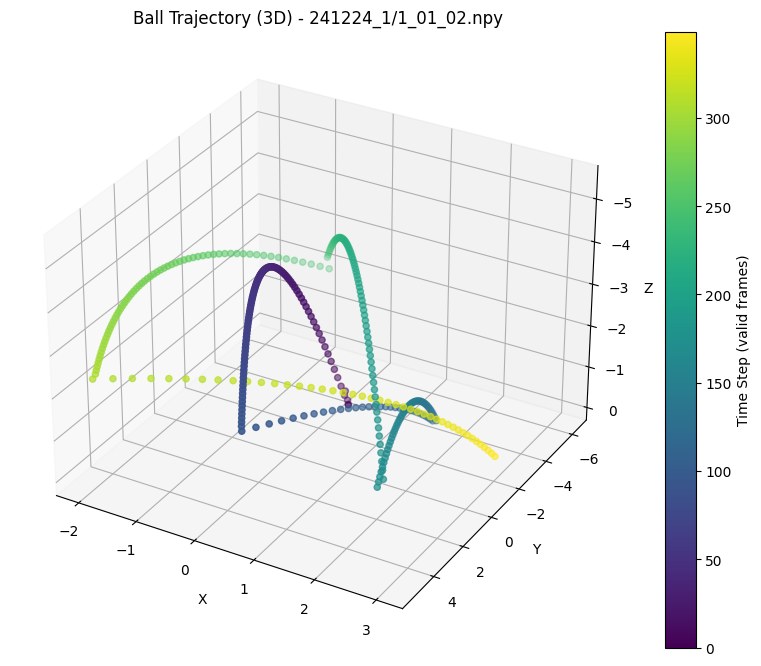

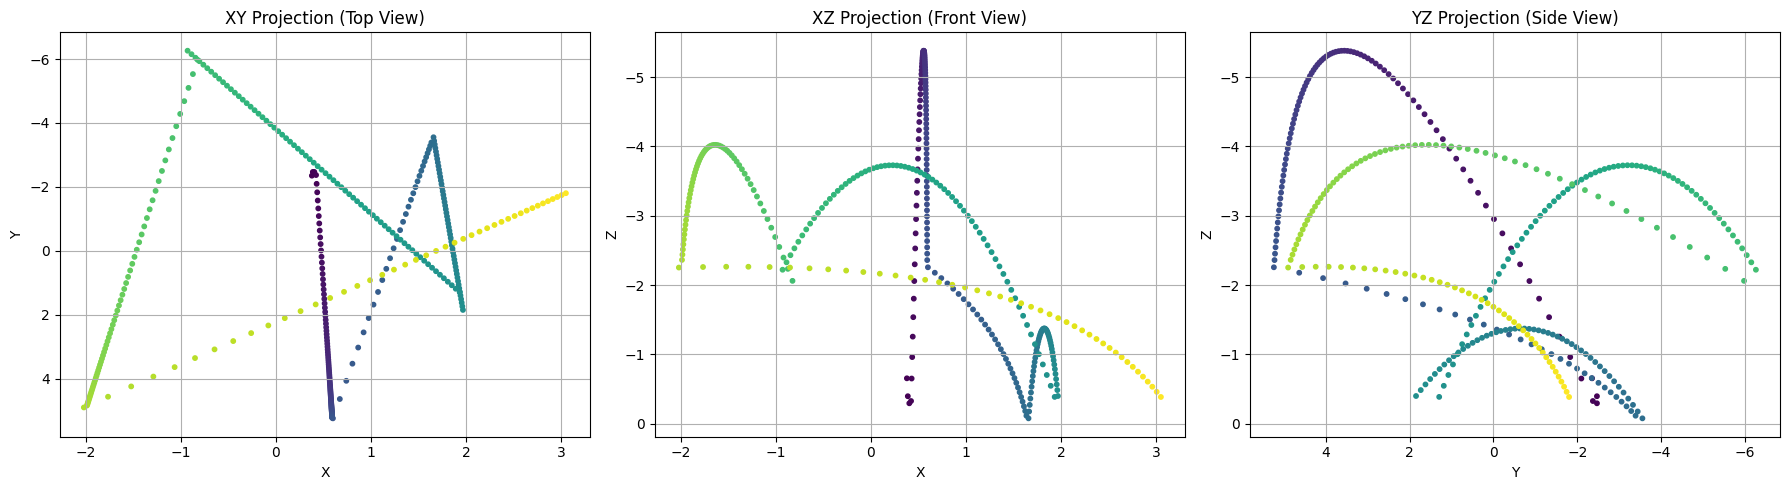

Visualizing: 1_02_02.npy, Valid points: 232


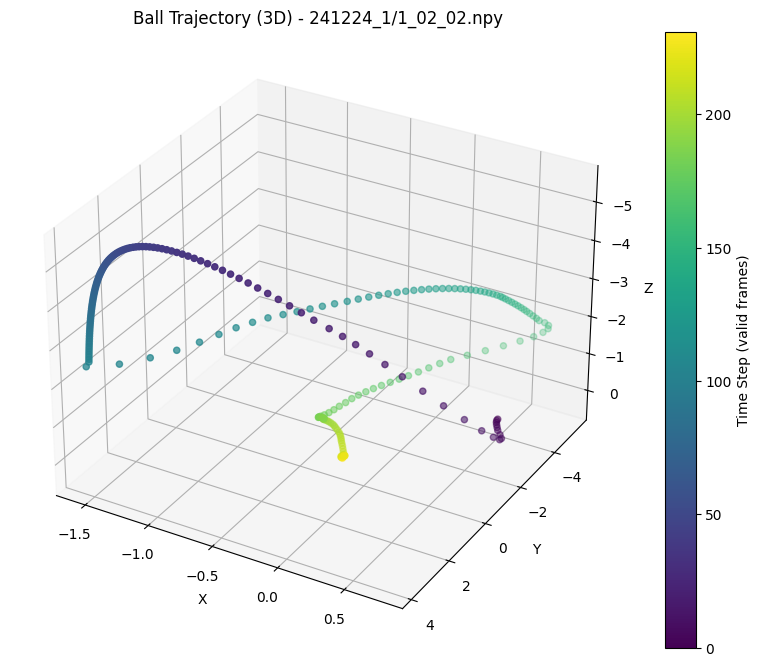

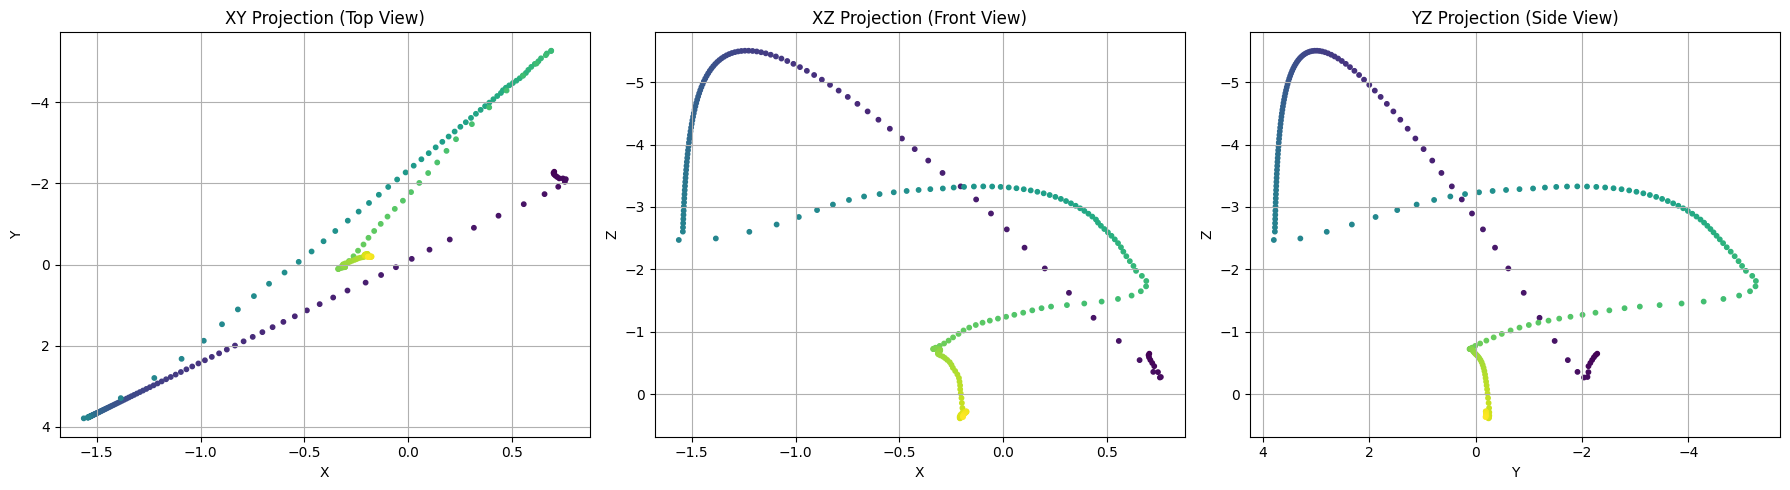

Visualizing: 1_02_03.npy, Valid points: 450


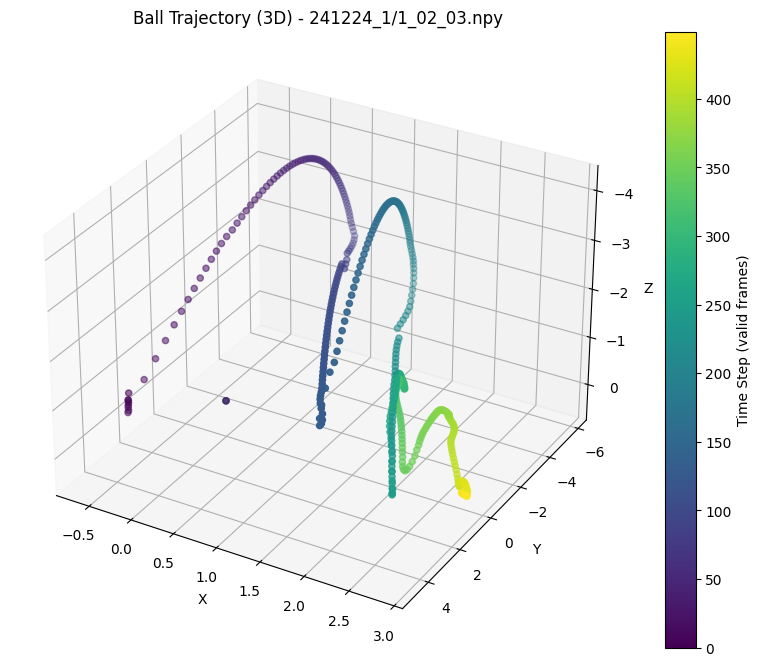

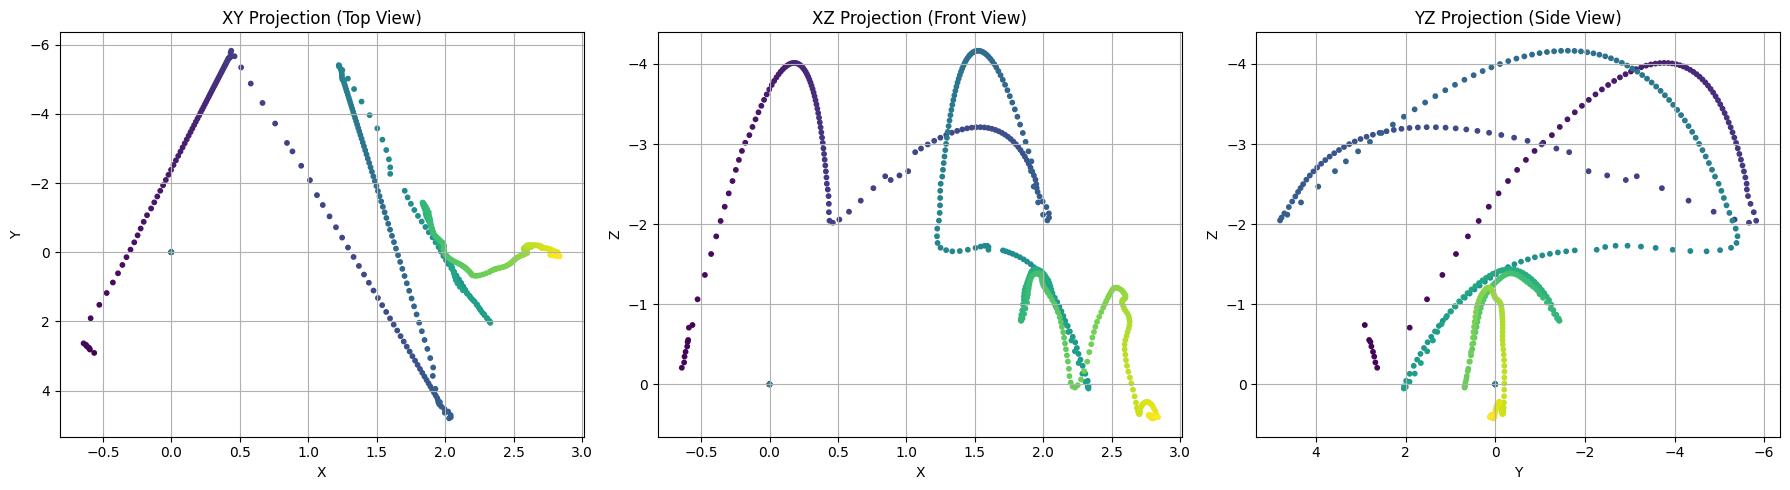

In [51]:
from pathlib import Path

# 指定要讀取的場次
rally_name = "241224_1"
ball_dir_path = Path(ball_dir) / rally_name

print(f"Iterating over files in: {ball_dir_path}")

# 遍歷資料夾中的每個檔案
# 為了避免一次畫太多圖當機，這裡先限制只畫前 5 個，您可以自行調整 [:5]
for file_path in sorted(list(ball_dir_path.glob("*.npy")))[:5]:
    file_name = file_path.name
    
    ball_path = os.path.join(ball_dir, rally_name, file_name)
    mask_path = os.path.join(mask_dir, rally_name, file_name)
    
    if os.path.exists(ball_path) and os.path.exists(mask_path):
        ball_data = np.load(ball_path)
        mask_data = np.load(mask_path)
        
        # 過濾掉 mask == 0 的點 (無效點)
        valid_indices = mask_data == 1
        
        # 如果沒有有效點，就跳過
        if np.sum(valid_indices) == 0:
            print(f"Skipping {file_name} (no valid points)")
            continue
            
        valid_ball_pos = ball_data[valid_indices]
        
        print(f"Visualizing: {file_name}, Valid points: {len(valid_ball_pos)}")

        # 建立 3D 圖
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # 繪製軌跡點
        # 3D scatter: (xs, ys, zs)
        # 這裡我們將 Data Z 映射到 Visual Z，Data Y 映射到 Visual Y
        sc = ax.scatter(valid_ball_pos[:, 0], valid_ball_pos[:, 2], valid_ball_pos[:, 1], c=np.arange(len(valid_ball_pos)), cmap='viridis', s=20)
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(f'Ball Trajectory (3D) - {rally_name}/{file_name}')
        
        # 顛倒 Y 軸
        ax.invert_yaxis()
        ax.invert_zaxis()

        # 加入顏色條表示時間順序
        cbar = plt.colorbar(sc, ax=ax, label='Time Step (valid frames)')
        
        plt.show()
        
        # 繪製 2D 投影 (XY, XZ, YZ)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # XY Plane (Top View)
        axes[0].scatter(valid_ball_pos[:, 0], valid_ball_pos[:, 2], c=np.arange(len(valid_ball_pos)), cmap='viridis', s=10)
        axes[0].set_xlabel('X')
        axes[0].set_ylabel('Y')
        axes[0].set_title('XY Projection (Top View)')
        axes[0].invert_yaxis() 
        axes[0].grid(True)

        # XZ Plane (Front View)
        axes[1].scatter(valid_ball_pos[:, 0], valid_ball_pos[:, 1], c=np.arange(len(valid_ball_pos)), cmap='viridis', s=10)
        axes[1].set_xlabel('X')
        axes[1].set_ylabel('Z')
        axes[1].set_title('XZ Projection (Front View)')
        axes[1].invert_yaxis()
        axes[1].grid(True)

        # # YZ Plane (Side View)
        axes[2].scatter(valid_ball_pos[:, 2], valid_ball_pos[:, 1], c=np.arange(len(valid_ball_pos)), cmap='viridis', s=10)
        axes[2].set_xlabel('Y')
        axes[2].set_ylabel('Z')
        axes[2].set_title('YZ Projection (Side View)')
        axes[2].invert_xaxis()
        axes[2].invert_yaxis()
        axes[2].grid(True)
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"Data not found for {file_name}")